In [19]:
import tensorflow as tf
import keras
import matplotlib.pyplot as plt 
import numpy as np
import seaborn as sns

In [20]:
import cv2

In [21]:
(x_train,y_train),(x_test,y_test) = keras.datasets.cifar10.load_data()

In [22]:
classes=["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

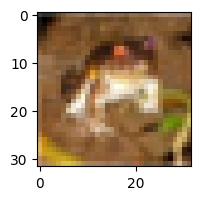

In [23]:
plt.figure(figsize=(15,2))
plt.imshow(x_train[0])

In [24]:
x_train[0].size

3072

10800
(60, 60, 3)


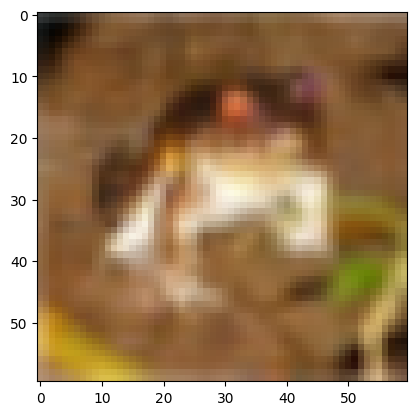

In [25]:
new_img=cv2.resize(x_train[0],(60,60))
print(new_img.size)
print(new_img.shape)
plt.imshow(new_img)
plt.show()

In [26]:
y_train

array([[6],
       [9],
       [9],
       ...,
       [9],
       [1],
       [1]], shape=(50000, 1), dtype=uint8)

In [27]:
y_train=y_train.reshape(-1,)
y_test=y_test.reshape(-1,)

In [28]:
from keras import layers, models

In [75]:
x_train=x_train/255
x_test=x_test/255

In [76]:
x_train[0]

array([[[0.23137255, 0.24313725, 0.24705882],
        [0.16862745, 0.18039216, 0.17647059],
        [0.19607843, 0.18823529, 0.16862745],
        ...,
        [0.61960784, 0.51764706, 0.42352941],
        [0.59607843, 0.49019608, 0.4       ],
        [0.58039216, 0.48627451, 0.40392157]],

       [[0.0627451 , 0.07843137, 0.07843137],
        [0.        , 0.        , 0.        ],
        [0.07058824, 0.03137255, 0.        ],
        ...,
        [0.48235294, 0.34509804, 0.21568627],
        [0.46666667, 0.3254902 , 0.19607843],
        [0.47843137, 0.34117647, 0.22352941]],

       [[0.09803922, 0.09411765, 0.08235294],
        [0.0627451 , 0.02745098, 0.        ],
        [0.19215686, 0.10588235, 0.03137255],
        ...,
        [0.4627451 , 0.32941176, 0.19607843],
        [0.47058824, 0.32941176, 0.19607843],
        [0.42745098, 0.28627451, 0.16470588]],

       ...,

       [[0.81568627, 0.66666667, 0.37647059],
        [0.78823529, 0.6       , 0.13333333],
        [0.77647059, 0

In [77]:
cnn= models.Sequential([
    
    layers.Conv2D(filters=16,kernel_size=(3,3),activation="relu"),
    layers.Dropout(0.2),
    # layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=32,kernel_size=(3,3),activation="relu"),
    layers.Dropout(0.2),
    # layers.MaxPooling2D((2,2)),
    layers.Conv2D(filters=64,kernel_size=(3,3),activation="relu"),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(64,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [78]:
cnn.compile(
    optimizer="adam",loss="sparse_categorical_crossentropy",metrics=["accuracy"]
)

In [79]:
from keras.callbacks import EarlyStopping

early_stop=EarlyStopping(
    monitor="val_loss",
    patience=5,
    restore_best_weights=True
)

In [80]:
history=cnn.fit(x_train,y_train,verbose=1,epochs=64,batch_size=32,callbacks=[early_stop],validation_split=0.2)

Epoch 1/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 112s 84ms/step - accuracy: 0.4241 - loss: 1.5665 - val_accuracy: 0.5290 - val_loss: 1.2961
Epoch 2/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 116s 64ms/step - accuracy: 0.5841 - loss: 1.1734 - val_accuracy: 0.6219 - val_loss: 1.0570
Epoch 3/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 81s 65ms/step - accuracy: 0.6442 - loss: 1.0099 - val_accuracy: 0.6463 - val_loss: 0.9996
Epoch 4/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.6836 - loss: 0.9030 - val_accuracy: 0.6498 - val_loss: 1.0024
Epoch 5/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 76s 61ms/step - accuracy: 0.7132 - loss: 0.8203 - val_accuracy: 0.6686 - val_loss: 0.9426
Epoch 6/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 74s 59ms/step - accuracy: 0.7387 - loss: 0.7521 - val_accuracy: 0.6799 - val_loss: 0.9210
Epoch 7/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 77s 62ms/step - accuracy: 0.7566 - loss: 0.6934 - val_accuracy: 0.6702 - val_loss: 0.9858
Epoch 8/64
1250/1250 ━━━━━━━━━━━━━━━━━━━━ 86s 65ms/step - accuracy: 0.7757

In [81]:
test_image=cv2.imread("frog.jpg")
test_image=test_image/255
test_image

array([[[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       [[1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        ...,
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ],
        [1.        , 1.        , 1.        ]],

       ...,

       [[0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0.99215686, 0.99215686],
        [0.99215686, 0

In [82]:
test_image.shape

(148, 225, 3)

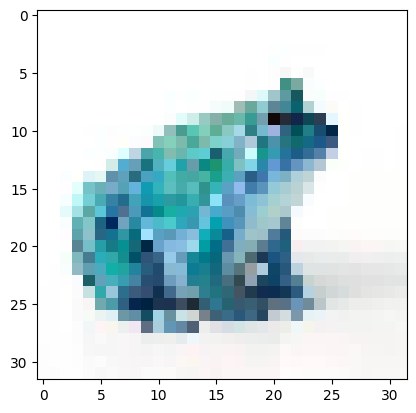

In [83]:
resize_test_image=cv2.resize(test_image,(32,32))
plt.imshow(resize_test_image)
plt.show()

In [84]:
resize_test_image=np.expand_dims(resize_test_image,axis=0)

In [85]:
prediction=cnn.predict(resize_test_image)
prediction

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 391ms/step


array([[6.1567813e-02, 8.0277210e-01, 2.9572735e-03, 6.1472383e-04,
        1.2560988e-05, 1.3807307e-04, 1.7810216e-02, 9.6054588e-05,
        1.9454235e-03, 1.1208581e-01]], dtype=float32)

In [86]:
index_predict=np.argmax(prediction)

In [87]:
classes[index_predict]

'automobile'